In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, log_loss, recall_score, f1_score, precision_score
from sklearn.neural_network import MLPClassifier

# Trenowanie najlepszego modelu

### Model A - klasyfikacja klatek (stoi/leży)

Podczas walidacji **LeaveOneGroupOut** wyniki modelu wyglądały następująco:

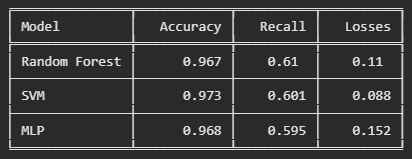

A więc wybrano model **SVM** jako **Model A**

Wczytanie danych A

In [2]:
data_path = '../data/dataset_urfall.npz'

if not os.path.exists(data_path):
    print(f"BŁĄD: Nie znaleziono pliku {data_path}")
else:
    print(f"Wczytuje dane z {data_path}...")
    with np.load(data_path) as data:
        sequences = data['sequences']
        X = data['X'] # znormalizowane punkty po preprocessingu
        y = data['y'] # etykiety (0 - stoi, 1 - leży)

    print(f"Wczytano {len(X)} próbek.")

print(f"\nKształt danych X (oryginalny): {X.shape}")
print(f"Kształt danych y: {y.shape}")
print(f"Liczba sekwencji: {len(np.unique(sequences))}")

# zmiana (N, 17, 2) -> (N, 34)
X = X.reshape(X.shape[0], -1)
print(f"\nKształt danych X (po reshape): {X.shape}")

Wczytuje dane z ../data/dataset_urfall.npz...
Wczytano 9627 próbek.

Kształt danych X (oryginalny): (9627, 17, 2)
Kształt danych y: (9627,)
Liczba sekwencji: 69

Kształt danych X (po reshape): (9627, 34)


Model A

--- PODZIAŁ DANYCH ---
Trening:    7792 filmów (80.9%)
Test:       1835 filmów (19.1%)

--- TRENOWANIE MODELU SVM ---
Zakończono trening

--- TESTOWANIE MODELU A - SVM ---
Accuracy: 0.967
              precision    recall  f1-score   support

         ADL       0.97      0.99      0.98      1408
        FALL       0.97      0.89      0.93       427

    accuracy                           0.97      1835
   macro avg       0.97      0.94      0.95      1835
weighted avg       0.97      0.97      0.97      1835



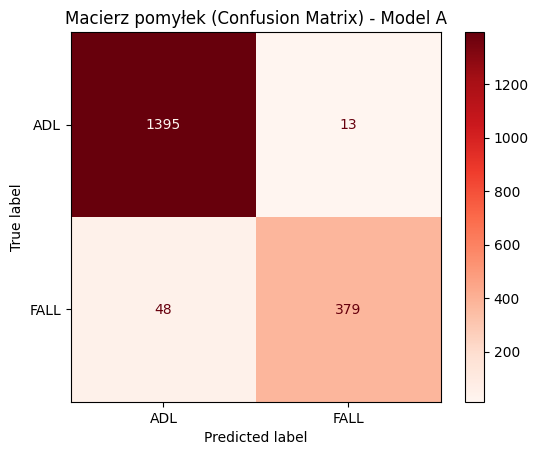

In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=67)

train_idx, test_idx = next(splitter.split(X, y, groups=sequences))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

total = len(X)
print("--- PODZIAŁ DANYCH ---")
print(f"Trening:    {len(X_train)} filmów ({len(X_train)/total:.1%})")
print(f"Test:       {len(X_test)} filmów ({len(X_test)/total:.1%})")

print("\n--- TRENOWANIE MODELU SVM ---")

model_1 = SVC(
    C=1,
    kernel='rbf',
    probability=True,
    random_state=67
)
model_1.fit(X_train, y_train)
print("Zakończono trening")

print("\n--- TESTOWANIE MODELU A - SVM ---")
y_pred_test = model_1.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"Accuracy: {acc_test:.3f}")
print(classification_report(y_test, y_pred_test, target_names=['ADL', 'FALL']))

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['ADL', 'FALL']).plot(cmap='Reds')
plt.title(f'Macierz pomyłek (Confusion Matrix) - Model A')
plt.show()

### Model B - klasyfikacja eventu (fall/adl)

Podczas walidacji **LeaveOneOut** wyniki modelu wyglądały następująco:

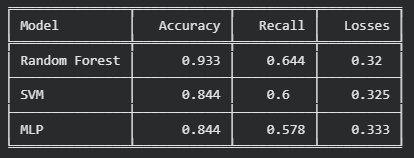

A więc wybrano model **Random Forest** jako **Model B**

Wczytanie danych B

In [4]:
data_path_2 = '../data/dataset_urfall_fe.npz'

if not os.path.exists(data_path_2):
    print(f"BŁĄD: Nie znaleziono pliku {data_path_2}")
else:
    print(f"Wczytuje dane z {data_path_2}...")
    with np.load(data_path_2) as data_2:
        sequences_2 = data_2['sequences']
        X_2 = data_2['X'] # sekwencje po agregacji cech
        y_2 = data_2['y'] # etykiety (0 - ADL, 1 - Fall)

    print(f"Wczytano {len(X_2)} próbek.")

print(f"\nKształt danych X (oryginalny): {X_2.shape}")
print(f"Kształt danych y: {y_2.shape}")
print(f"Liczba sekwencji: {len(np.unique(sequences_2))}")

# zmiana (N, 136, 2) -> (N, 272)
X_2 = X_2.reshape(X_2.shape[0], -1)
print(f"\nKształt danych X (po reshape): {X_2.shape}")

Wczytuje dane z ../data/dataset_urfall_fe.npz...
Wczytano 45 próbek.

Kształt danych X (oryginalny): (45, 136, 2)
Kształt danych y: (45,)
Liczba sekwencji: 45

Kształt danych X (po reshape): (45, 272)


Model B

--- PODZIAŁ DANYCH ---
Trening:    33 filmów (73.3%)
Test:       12 filmów (26.7%)

--- TRENOWANIE MODELU Random Forest ---
Zakończono trening

--- TESTOWANIE MODELU B - Random Forest ---
Accuracy: 1.000
              precision    recall  f1-score   support

         ADL       1.00      1.00      1.00         4
        FALL       1.00      1.00      1.00         8

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



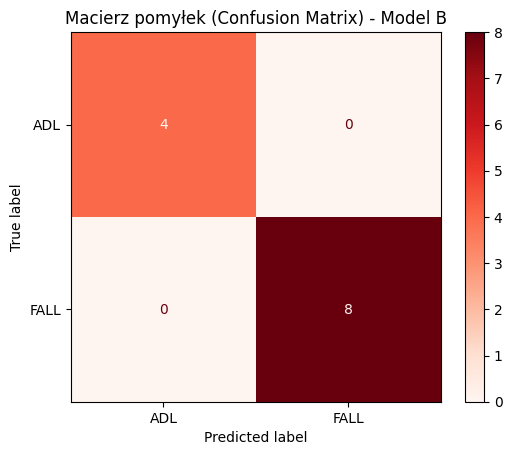

In [5]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.25, random_state=67, stratify=y_2)


total = len(X_2)
print("--- PODZIAŁ DANYCH ---")
print(f"Trening:    {len(X_train_2)} filmów ({len(X_train_2)/total:.1%})")
print(f"Test:       {len(X_test_2)} filmów ({len(X_test_2)/total:.1%})")

print("\n--- TRENOWANIE MODELU Random Forest ---")

model_2 = RandomForestClassifier(
    n_estimators=100,
    random_state=67,
    n_jobs=-1
)
model_2.fit(X_train_2, y_train_2)
print("Zakończono trening")

print("\n--- TESTOWANIE MODELU B - Random Forest ---")
y_pred_test_2 = model_2.predict(X_test_2)
acc_test_2 = accuracy_score(y_test_2, y_pred_test_2)
print(f"Accuracy: {acc_test_2:.3f}")
print(classification_report(y_test_2, y_pred_test_2, target_names=['ADL', 'FALL']))

cm_2 = confusion_matrix(y_test_2, y_pred_test_2)
ConfusionMatrixDisplay(cm_2, display_labels=['ADL', 'FALL']).plot(cmap='Reds')
plt.title(f'Macierz pomyłek (Confusion Matrix) - Model B')
plt.show()

# Pipeline

### Funkcje pomocnicze

Funkcja do normalizacji keypointów względem środka bioder

In [6]:
def normalize_frame(keypoints):
    kps = np.array(keypoints)

    # pozycje bioder
    left_hip = 11
    right_hip = 12

    # pozycja środka bioder
    hip_center = (kps[left_hip] + kps[right_hip]) / 2.0

    # centrownie punktów względem bioder
    centered_kps = kps - hip_center

    # skalowanie - wybieramy najwyżej i najniżej położone keypointy na osi Y jako odniesienie do wyznaczenia wysokości
    min_y = np.min(centered_kps[:, 1])
    max_y = np.max(centered_kps[:, 1])
    height = max_y - min_y + 1e-6 # dodaje bardzo małą wartość aby uniknąć dzielenia przez 0

    normalized_kps = centered_kps / height

    return normalized_kps

Funkcja do wczytywania keypointów z jsona

In [7]:
import json

def load_json(json_path):

    keypoints = []

    # --- wczytanie jsona ---
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Błąd odczytu {json_path}: {e}")

    # --- ekstrakcja klatek ---
    if 'instance_info' not in data:
        print(f"Brak pola 'instace_info' w {json_path}")

    # sortowanie klatek dla pewności
    frames_data = sorted(data['instance_info'], key=lambda x: x['frame_id'])

    for frame in data['instance_info']:

        frame_id = frame['frame_id']

        # --- ekstrakcja punktów ---
        if not frame.get("instances"):
            continue

        raw_kps = frame['instances'][0]['keypoints'] # zakładamy jedną osobę

        # normalizacja względem bioder
        norm_kps = normalize_frame(raw_kps)
        keypoints.append(norm_kps.reshape(-1))

    print("="*50)
    print(f"Wczytano keypointy z pliku '{os.path.basename(json_path)}'")
    return np.array(keypoints)


Funkcja do wyliczania dynamiki postaci na wideo

In [8]:
def extract_features(json_keypoints):
    # obliczamy cechy fizyczne jak prędkość, przyspieszenie itp
    velocity = np.diff(json_keypoints, axis=0) # prędkość
    if len(velocity) == 0: velocity = np.zeros((1, 34))

    acceleration = np.diff(velocity, axis=0) # przyspieszenie
    if len(acceleration) == 0: acceleration = np.zeros((1, 34))

    # agregacja zmiana filmu na jeden wektor
    stats = []

    # statystyki pozycji
    # min/max/mean/std dla każdej współrzędnej
    stats.extend([
        np.mean(json_keypoints, axis=0),
        np.std(json_keypoints, axis=0),
        np.max(json_keypoints, axis=0),
        np.min(json_keypoints, axis=0)
    ])

    # statystyki prędkości
    stats.extend([
        np.mean(np.abs(velocity), axis=0),
        np.max(np.abs(velocity), axis=0),
        np.std(velocity, axis=0)
    ])

    # statystyki przyspieszenia
    stats.extend([
        np.max(np.abs(acceleration), axis=0)
    ])

    seq_features = np.concatenate(stats)

    return seq_features.reshape(1, -1)

        # features.append(seq_features)

### PIPELINE FALL DETECTION

In [9]:
def fall_detection_pipeline(json_keypoints, model_A, model_B):
    """
    json_keypoints: surowa macierz (N, 34) z pliku JSON, uzyskana funkcją `load_json`
    """
    print("\n----- ANALIZA WIDEO -----")

    detected_lying = False
    lying_frame_counter = 0

    # iteracja po klatkach wideo
    for i, frame in enumerate(json_keypoints):
        frame_reshaped = frame.reshape(1, -1)

        # klasyfikacja klatki - model A
        pose_prediction = model_A.predict(frame_reshaped)[0]
        pose_propability = model_A.predict_proba(frame_reshaped)[0]

        if pose_prediction == 1:
            lying_frame_counter += 1
        else:
            lying_frame_counter = 0

        # jeżeli wykryto 3 klatki z rzędu w których postać leży to break
        if lying_frame_counter >= 3:
            detected_lying = True
            break

    if not detected_lying:
        print("WYNIK: ADL (osoba nie przyjeła pozycji leżącej)")
        print(f"(Pewność: {(pose_propability[0] * 100):.2f}%)")
        return 0

    # analiza dynamiki ponieważ postać
    sequences_features = extract_features(json_keypoints)

    # klasyfikacja zdarzenia - model B
    event_prediction = model_B.predict(sequences_features)[0]
    event_probability = model_B.predict_proba(sequences_features)[0]

    if event_prediction == 1:
        print(f"WYNIK: UPADEK (FALL) !!!")
        print(f"(Pewność: {(event_probability[1] * 100):.2f}%)")
        return 1
    else:
        print(f"WYNIK: ADL (Czynność codzienna) !!!")
        print(f"(Pewność: {(event_probability[0] * 100):.2f}%)")
        return 0

Sprawdzenie wszystkich plików

In [14]:
import glob

folder_path = "../results/"

search_pattern = os.path.join(folder_path, "*", "*.json")
all_files = glob.glob(search_pattern)

correct = 0
total = 0
errors = 0
errors_tab = []

for video in tqdm(all_files):
    video_keypoints = load_json(video)

    base_name = os.path.basename(video)

    decision = fall_detection_pipeline(video_keypoints, model_1, model_2)

    if base_name.__contains__('adl') and decision == 0:
        correct += 1
        print("\n✅ Model zgadł poprawnie! Jest to ADL")
    elif base_name.__contains__('fall') and decision == 1:
        correct += 1
        print("\n✅ Model zgadł poprawnie! Jest to FALL")
    else:
        errors += 1
        errors_tab.append(base_name)
        print("\n❌ Model się pomylił.")
        if base_name.__contains__('adl'):
            print("Jest to ADL")
        else:
            print("Jest to FALL")
    total += 1

print("\n\n" + "="*50)
accuracy = (correct / total) * 100
print(f"SKUTECZNOŚĆ NA ZBIORZE UR_FALL_DETECTION: {accuracy:.2f}%")
print(f'Poprawne: {correct} | Błędne: {errors}')

print("\nBłędne przewidywania:")
for i in errors_tab:
    print(i)

  1%|▏         | 1/69 [00:00<00:08,  7.67it/s]

Wczytano keypointy z pliku 'results_adl-01-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (osoba nie przyjeła pozycji leżącej)
(Pewność: 99.21%)

✅ Model zgadł poprawnie! Jest to ADL
Wczytano keypointy z pliku 'results_adl-02-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----


  3%|▎         | 2/69 [00:00<00:10,  6.12it/s]

WYNIK: ADL (osoba nie przyjeła pozycji leżącej)
(Pewność: 99.85%)

✅ Model zgadł poprawnie! Jest to ADL
Wczytano keypointy z pliku 'results_adl-03-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----


  6%|▌         | 4/69 [00:00<00:11,  5.50it/s]

...

WYNIK: ADL (Czynność codzienna) !!!
(Pewność: 58.00%)

❌ Model się pomylił.
Jest to FALL
Wczytano keypointy z pliku 'results_fall-24-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: UPADEK (FALL) !!!
(Pewność: 94.00%)

✅ Model zgadł poprawnie! Jest to FALL
Wczytano keypointy z pliku 'results_fall-25-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (Czynność codzienna) !!!
(Pewność: 50.00%)

❌ Model się pomylił.
Jest to FALL
Wczytano keypointy z pliku 'results_fall-26-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (Czynność codzienna) !!!
(Pewność: 57.00%)

❌ Model się pomylił.
Jest to FALL
Wczytano keypointy z pliku 'results_fall-27-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----


 96%|█████████▌| 66/69 [00:09<00:00,  9.71it/s]

WYNIK: UPADEK (FALL) !!!
(Pewność: 55.00%)

✅ Model zgadł poprawnie! Jest to FALL
Wczytano keypointy z pliku 'results_fall-28-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: UPADEK (FALL) !!!
(Pewność: 72.00%)

✅ Model zgadł poprawnie! Jest to FALL
Wczytano keypointy z pliku 'results_fall-29-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----


100%|██████████| 69/69 [00:10<00:00,  6.78it/s]

WYNIK: UPADEK (FALL) !!!
(Pewność: 76.00%)

✅ Model zgadł poprawnie! Jest to FALL
Wczytano keypointy z pliku 'results_fall-30-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: UPADEK (FALL) !!!
(Pewność: 80.00%)

✅ Model zgadł poprawnie! Jest to FALL


SKUTECZNOŚĆ NA ZBIORZE UR_FALL_DETECTION: 95.65%
Poprawne: 66 | Błędne: 3

Błędne przewidywania:
results_fall-23-cam0-rgb-vis.json
results_fall-25-cam0-rgb-vis.json
results_fall-26-cam0-rgb-vis.json


Użycie na pojedynczym wideo

Model błędnie klasyfikował poniższe 3 sekwencje z datasetu **UR Fall Detection**:
-    fall-23-cam0-rgb-vis
-    fall-25-cam0-rgb-vis
-    fall-26-cam0-rgb-vis

In [11]:
single_video_path = "../results/fall-26-cam0-rgb-vis"
keypoints_path = glob.glob(os.path.join(single_video_path, "*.json"))[0]

print(keypoints_path)

video_keypoints = load_json(keypoints_path)

base_name = os.path.basename(keypoints_path)

# print(video_keypoints.shape)
# x = extract_features(video_keypoints)
# print(x.shape)

decision = fall_detection_pipeline(video_keypoints, model_1, model_2)

if base_name.__contains__('adl') and decision == 0:
    print("\n✅ Model zgadł poprawnie! Jest to ADL")
elif base_name.__contains__('fall') and decision == 1:
    print("\n✅ Model zgadł poprawnie! Jest to FALL")
else:
    print("\n❌ Model się pomylił.")
    if base_name.__contains__('adl'):
        print("Jest to ADL")
    else:
        print("Jest to FALL")


../results/fall-26-cam0-rgb-vis\results_fall-26-cam0-rgb-vis.json
Wczytano keypointy z pliku 'results_fall-26-cam0-rgb-vis.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (Czynność codzienna) !!!
(Pewność: 57.00%)

❌ Model się pomylił.
Jest to FALL


Wyświetlenie pojedynczego wideo

In [52]:
from IPython.display import Video
import cv2

video_path = glob.glob(os.path.join(single_video_path, "*.mp4"))[0]

# wyświetlenie wideo za pomocą biblioteki OpenCV
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Błąd: Nie można otworzyć pliku wideo.")
else:
    print(f"Odtwarzam wideo za pomocą OpenCV: {base_name}")
    print("Naciśnij 'q' na klawiaturze (w oknie wideo), aby zamknąć.")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if ret:
            # Wyświetlanie klatki w oknie
            cv2.imshow(f'{base_name}', frame)
            
            # Czekaj 25ms (ok. 40 FPS) i sprawdź czy wciśnięto 'q'
            if cv2.waitKey(25) & 0xFF == ord('q'):
                break
        else:
            break

    cap.release()
    cv2.destroyAllWindows()

Odtwarzam wideo za pomocą OpenCV: results_fall-26-cam0-rgb-vis.json
Naciśnij 'q' na klawiaturze (w oknie wideo), aby zamknąć.


### Testowanie na dodatkowych video z innego datasetu

In [15]:
import glob

folder_path = "../Fall_vid_det/results/"

search_pattern = os.path.join(folder_path, "*", "*.json")
all_files = glob.glob(search_pattern)

correct = 0
total = 0
errors = 0
errors_tab = []

for video in tqdm(all_files):
    video_keypoints = load_json(video)

    base_name = os.path.basename(video)

    decision = fall_detection_pipeline(video_keypoints, model_1, model_2)

    if base_name.__contains__('adl') and decision == 0:
        correct += 1
        print("\n✅ Model zgadł poprawnie! Jest to ADL")
    elif base_name.__contains__('fall') and decision == 1:
        correct += 1
        print("\n✅ Model zgadł poprawnie! Jest to FALL")
    else:
        errors += 1
        errors_tab.append(base_name)
        print("\n❌ Model się pomylił.")
        if base_name.__contains__('adl'):
            print("Jest to ADL")
        else:
            print("Jest to FALL")
    total += 1

print("\n\n" + "="*50)
accuracy = (correct / total) * 100
print(f"SKUTECZNOŚĆ NA ZBIORZE DODATKOWYM: {accuracy:.2f}%")
print(f'Poprawne: {correct} | Błędne: {errors}')

print("\nBłędne przewidywania:")
for i in errors_tab:
    print(i)

 50%|█████     | 3/6 [00:00<00:00, 25.06it/s]

Wczytano keypointy z pliku 'results_adl_1.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (osoba nie przyjeła pozycji leżącej)
(Pewność: 3.23%)

✅ Model zgadł poprawnie! Jest to ADL
Wczytano keypointy z pliku 'results_adl_2.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (osoba nie przyjeła pozycji leżącej)
(Pewność: 99.98%)

✅ Model zgadł poprawnie! Jest to ADL
Wczytano keypointy z pliku 'results_adl_3.json'

----- ANALIZA WIDEO -----
WYNIK: ADL (osoba nie przyjeła pozycji leżącej)
(Pewność: 22.53%)

✅ Model zgadł poprawnie! Jest to ADL
Wczytano keypointy z pliku 'results_fall_1.json'

----- ANALIZA WIDEO -----


100%|██████████| 6/6 [00:00<00:00, 15.43it/s]

WYNIK: UPADEK (FALL) !!!
(Pewność: 67.00%)

✅ Model zgadł poprawnie! Jest to FALL
Wczytano keypointy z pliku 'results_fall_2.json'

----- ANALIZA WIDEO -----
WYNIK: UPADEK (FALL) !!!
(Pewność: 72.00%)

✅ Model zgadł poprawnie! Jest to FALL
Wczytano keypointy z pliku 'results_fall_3.json'

----- ANALIZA WIDEO -----
WYNIK: UPADEK (FALL) !!!
(Pewność: 76.00%)

✅ Model zgadł poprawnie! Jest to FALL


SKUTECZNOŚĆ NA ZBIORZE DODATKOWYM: 100.00%
Poprawne: 6 | Błędne: 0

Błędne przewidywania:
